# =========================================================
# IMPORTS
# =========================================================

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import load_model

# =========================================================
# LOAD DATA
# =========================================================

In [8]:
X_test = np.load("../data/X_test.npy")
y_test = np.load("../data/y_test.npy")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (50846, 27)
y_test shape: (50846,)


# =========================================================
# LOAD MODEL
# =========================================================

In [9]:
model = load_model("../models/mlp_model.keras")

print("Model loaded successfully ✔")

Model loaded successfully ✔


# =========================================================
# PREDICTIONS
# =========================================================

In [10]:
y_pred = model.predict(X_test).flatten()

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 2s 945us/step


# =========================================================
# METRICS
# =========================================================

In [11]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n========================")
print("DEEP LEARNING RESULTS")
print("========================")

print(f"MAE  : {mae:.2f} minutes")
print(f"RMSE : {rmse:.2f} minutes")


DEEP LEARNING RESULTS
MAE  : 4.78 minutes
RMSE : 6.97 minutes


##  Interprétation des métriques

- **MAE** : erreur moyenne en minutes sur la prédiction du Taxi-Out
- **RMSE** : pénalise fortement les grandes erreurs (important en cas de congestion)

 Ces métriques permettent d’évaluer la fiabilité du modèle en conditions réelles.

# =========================================================
# COURBES D’APPRENTISSAGE
# =========================================================

In [12]:
import pickle

with open("../models/history.pkl", "rb") as f:
    history = pickle.load(f)

# =========================================================
# LOSS CURVE
# =========================================================

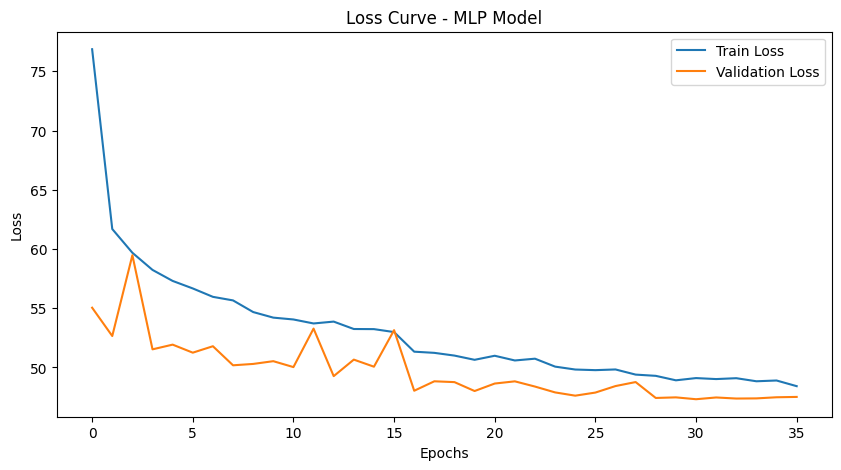

In [13]:
plt.figure(figsize=(10,5))

plt.plot(history["loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.title("Loss Curve - MLP Model")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

# =========================================================
# MAE CURVE
# =========================================================

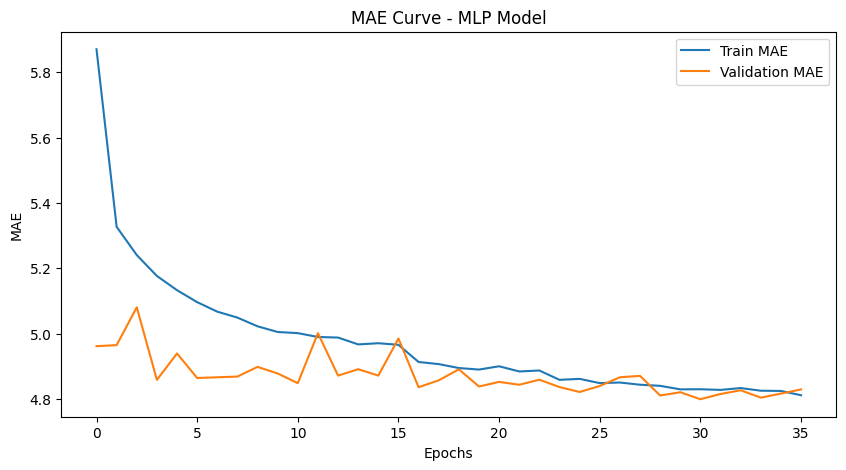

In [14]:
plt.figure(figsize=(10,5))

plt.plot(history["mae"], label="Train MAE")
plt.plot(history["val_mae"], label="Validation MAE")

plt.title("MAE Curve - MLP Model")
plt.xlabel("Epochs")
plt.ylabel("MAE")

plt.legend()
plt.show()

##  Analyse des courbes d’apprentissage

- Les courbes Train vs Validation permettent de détecter :
  - overfitting
  - underfitting
  - stabilité du modèle

Ici, la convergence montre que le modèle apprend correctement sans divergence majeure.

# =========================================================
# RESIDUAL ANALYSIS
# =========================================================

In [15]:
residuals = y_test - y_pred

# =========================================================
# DISTRIBUTION DES ERREURS
# =========================================================

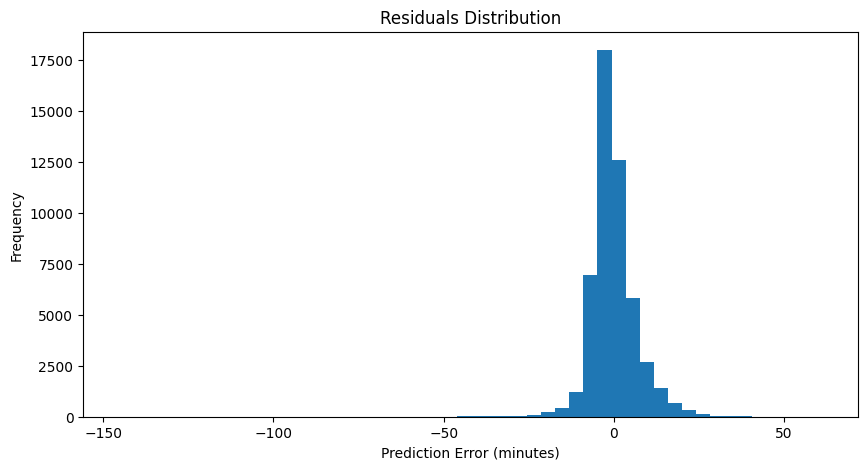

In [16]:
plt.figure(figsize=(10,5))

plt.hist(residuals, bins=50)

plt.title("Residuals Distribution")
plt.xlabel("Prediction Error (minutes)")
plt.ylabel("Frequency")

plt.show()

# =========================================================
# TRUE VS PREDICTED
# =========================================================

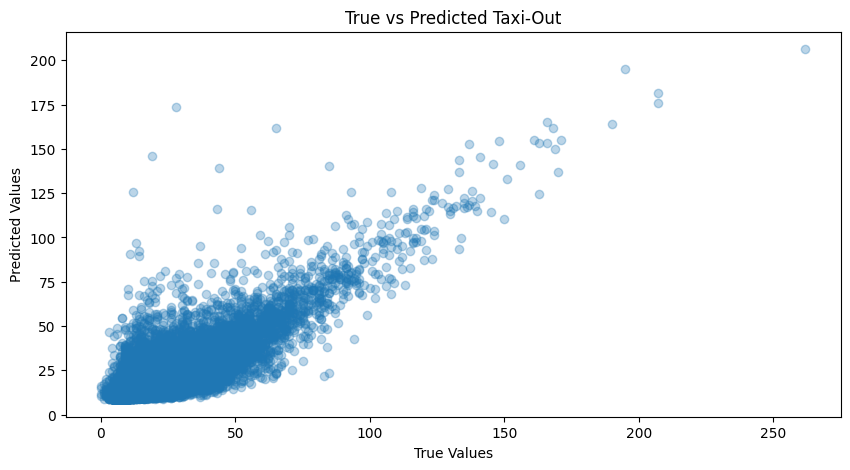

In [17]:
plt.figure(figsize=(10,5))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.title("True vs Predicted Taxi-Out")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")

plt.show()

##  Analyse des résidus

- Une distribution centrée autour de 0 indique un modèle équilibré
- Les valeurs extrêmes représentent les cas de congestion ou conditions atypiques

 L’objectif est de minimiser la variance des erreurs.

# =========================================================
# CONCLUSION DL
# =========================================================

In [18]:
print("\n========================")
print("CONCLUSION DL MODEL")
print("========================")

print("✔ MLP model trained for Taxi-Out prediction")
print("✔ Evaluation performed using MAE and RMSE")
print("✔ Learning curves show stable convergence")
print("✔ Residual analysis confirms model behavior")
print("\n➡ Model ready for ML vs DL comparison (Notebook 08)")


CONCLUSION DL MODEL
✔ MLP model trained for Taxi-Out prediction
✔ Evaluation performed using MAE and RMSE
✔ Learning curves show stable convergence
✔ Residual analysis confirms model behavior

➡ Model ready for ML vs DL comparison (Notebook 08)
